# RQ2a — Effect of Number of Committed Peers
Sweeps n_com ∈ {0, 2, 4, 6} with authority absent. Shows how conformity scales with peer commitment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

RESULTS_DIR = Path("../results_todos/rq2a")

RQ2A_CONDITIONS = ["rq2a_commit0", "rq2a_commit2", "rq2a_commit4", "rq2a_commit6"]
CONDITION_LABELS = {
    "rq2a_commit0": "0 committed",
    "rq2a_commit2": "2 committed",
    "rq2a_commit4": "4 committed",
    "rq2a_commit6": "6 committed",
}
N_COM = [0, 2, 4, 6]

per_seed_dfs = []
for csv_path in sorted(RESULTS_DIR.rglob("*.metrics.csv")):
    if "_all_seeds" in csv_path.name:
        continue
    parts = csv_path.parts
    if not any(p.startswith("seed_") for p in parts):
        continue
    df = pd.read_csv(csv_path)
    df = df[df["condition"].isin(RQ2A_CONDITIONS + ["ALL"])]
    if not df.empty:
        per_seed_dfs.append(df)

all_per_seed = pd.concat(per_seed_dfs, ignore_index=True) if per_seed_dfs else pd.DataFrame()
combined = all_per_seed.groupby(["model", "condition"]).mean(numeric_only=True).reset_index()

MODELS = sorted(combined["model"].unique())
PALETTE = sns.color_palette("tab10", len(MODELS))
MODEL_COLORS = dict(zip(MODELS, PALETTE))

print(f"Models: {MODELS}")
print(f"Conditions: {sorted(combined['condition'].unique())}")


Models: ['llama31_it', 'mistral_it', 'phi35_it', 'qwen25_it']
Conditions: ['ALL', 'rq2a_commit0', 'rq2a_commit2', 'rq2a_commit4', 'rq2a_commit6']


## Per-model metrics tables

> **Note on baseline (acc_r1):** Fractional values in the `n` column reflect that Mistral had skipped rows (malformed JSON outputs) across seeds, so the average is non-integer. The baseline acc_r1 for Mistral (~45%) may differ from RQ1 (~56%) if a different random sample of 500 functions was used at generation time — verify both datasets were generated with the same `--seed` and `--input` file.

In [2]:
display_cols = ["condition", "n", "acc_r1", "acc_r2", "delta_acc",
                "rev_pct", "harm_pct", "ben_pct", "mean_dC"]

for model in MODELS:
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin(RQ2A_CONDITIONS))].copy()
    present = [c for c in RQ2A_CONDITIONS if c in df_m["condition"].values]
    df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
    df_m = df_m.sort_values("condition")[display_cols].reset_index(drop=True)
    print(f"\n{'─'*60}\n  {model.upper()}\n{'─'*60}")
    display(df_m.style
        .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                 **{c: "{:.1f}" for c in ["acc_r1","acc_r2","delta_acc","rev_pct","harm_pct","ben_pct","mean_dC"]}}, na_rep="N/A")
        .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
        .background_gradient(subset=["harm_pct"], cmap="Reds", vmin=0, vmax=100)
        .background_gradient(subset=["ben_pct"], cmap="Greens", vmin=0, vmax=100)
        .set_caption(model))



────────────────────────────────────────────────────────────
  LLAMA31_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,500,53.1,53.0,-0.1,32.2,30.4,34.2,-1.4
1,rq2a_commit2,500,53.1,52.0,-1.1,30.3,29.6,31.1,-0.7
2,rq2a_commit4,500,53.1,50.5,-2.7,29.6,30.4,28.7,-0.8
3,rq2a_commit6,500,53.1,50.1,-3.0,30.6,31.7,29.4,-0.7



────────────────────────────────────────────────────────────
  MISTRAL_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,403.90,47.8,42.4,-5.4,23.2,23.1,3.1,-1.9
1,rq2a_commit2,399.10,47.9,48.3,0.4,18.2,9.6,9.5,-0.4
2,rq2a_commit4,397.60,47.8,46.2,-1.6,23.1,16.2,10.4,-0.1
3,rq2a_commit6,394.70,47.9,44.9,-3.0,26.8,19.8,10.3,-0.2



────────────────────────────────────────────────────────────
  PHI35_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,500,50.4,50.4,0.0,0.0,0.0,0.0,0.0
1,rq2a_commit2,500,50.4,50.2,-0.2,1.2,1.4,1.0,-0.0
2,rq2a_commit4,500,50.4,50.8,0.4,2.4,2.0,2.8,0.0
3,rq2a_commit6,500,50.4,50.2,-0.2,1.8,2.0,1.6,0.0



────────────────────────────────────────────────────────────
  QWEN25_IT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct,mean_dC
0,rq2a_commit0,500,58.2,55.4,-2.8,17.8,17.7,18.2,0.3
1,rq2a_commit2,500,58.2,53.2,-5.0,31.4,31.2,31.8,0.8
2,rq2a_commit4,500,58.2,53.5,-4.7,29.4,29.3,29.6,0.8
3,rq2a_commit6,500,58.2,51.5,-6.7,37.3,37.8,36.6,0.8


## Δ Accuracy vs n_com (line plot per model)

> **Note:** `rq2a_commit6` is structurally identical to RQ1 `mixed_absent` (same peer prompt, same instances). Do not combine these two data sources in any joint analysis.

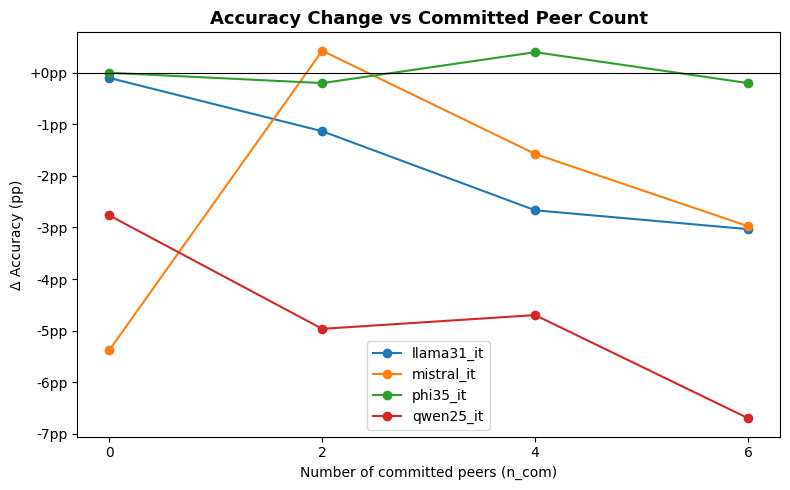

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
for model in MODELS:
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin([f"rq2a_commit{n}" for n in N_COM]))].copy()
    df_m["n_com"] = df_m["condition"].str.extract(r"commit(\d+)").astype(int)
    df_m = df_m.sort_values("n_com")
    ax.plot(df_m["n_com"], df_m["delta_acc"], marker="o", label=model)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Number of committed peers (n_com)")
ax.set_ylabel("\u0394 Accuracy (pp)")
ax.set_title("Accuracy Change vs Committed Peer Count", fontsize=13, fontweight="bold")
ax.set_xticks(N_COM)
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rq2a_delta_acc_vs_ncom.png", dpi=150, bbox_inches="tight")
plt.show()


## Harmful % vs n_com

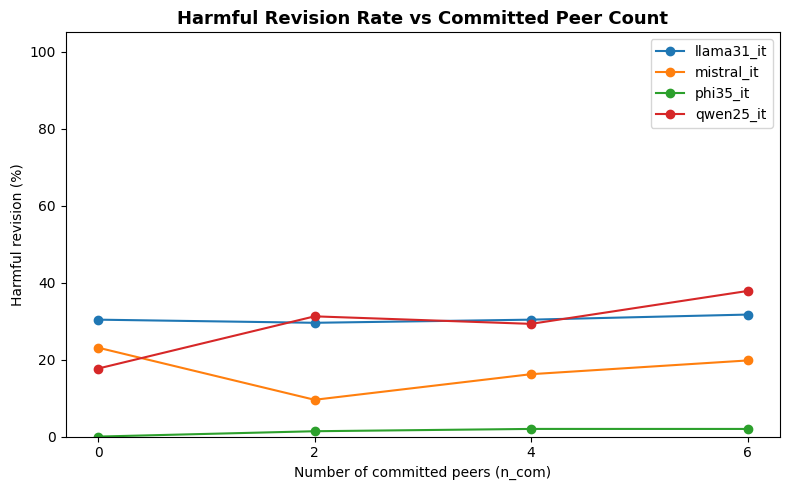

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for model in MODELS:
    df_m = combined[(combined["model"] == model) & (combined["condition"].isin([f"rq2a_commit{n}" for n in N_COM]))].copy()
    df_m["n_com"] = df_m["condition"].str.extract(r"commit(\d+)").astype(int)
    df_m = df_m.sort_values("n_com")
    ax.plot(df_m["n_com"], df_m["harm_pct"], marker="o", label=model)

ax.set_xlabel("Number of committed peers (n_com)")
ax.set_ylabel("Harmful revision (%)")
ax.set_title("Harmful Revision Rate vs Committed Peer Count", fontsize=13, fontweight="bold")
ax.set_xticks(N_COM)
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rq2a_harmful_vs_ncom.png", dpi=150, bbox_inches="tight")
plt.show()


## Δ Accuracy heatmap — models × conditions

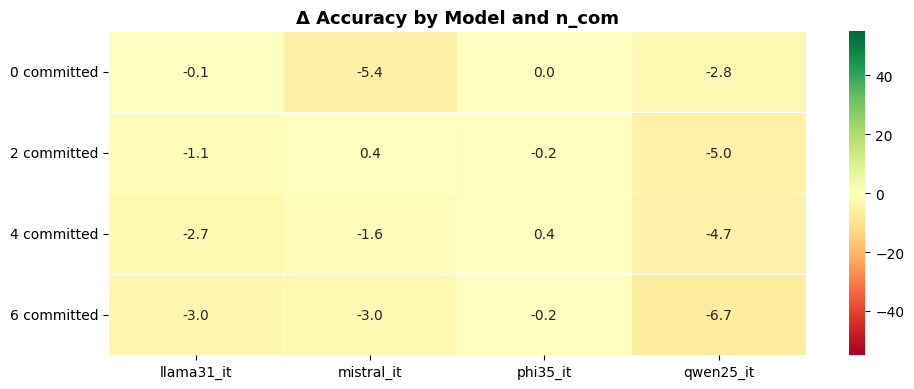

In [5]:
df_plot = combined[combined["condition"].isin([f"rq2a_commit{n}" for n in N_COM])]
pivot = df_plot.pivot_table(index="condition", columns="model", values="delta_acc")
pivot = pivot.reindex([f"rq2a_commit{n}" for n in N_COM if f"rq2a_commit{n}" in pivot.index])
fig, ax = plt.subplots(figsize=(max(6, 2.5*len(MODELS)), 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
            linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("\u0394 Accuracy by Model and n_com", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels([CONDITION_LABELS.get(c, c) for c in pivot.index], rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rq2a_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
